# Brain Connectivity Analysis: Child vs Adult

# Load Dataset

In [2]:
from nilearn import datasets

# 1. Fetch the dataset (This downloads ~50MB, very fast)
# I'll use the 'development_fmri' dataset which includes children and adults
dataset = datasets.fetch_development_fmri(n_subjects=10)

# 2. Let's look at what I got
print(f"Keys in the dataset: {dataset.keys()}")
print(f"Number of subjects: {len(dataset.func)}")
print(f"First subject's brain image path: {dataset.func[0]}")

# 3. Look at the phenotype (Age, Sex, etc.)
import pandas as pd
pheno = pd.DataFrame(dataset.phenotypic)
print(pheno[['Child_Adult', 'Age', 'Gender']].head())

[fetch_development_fmri] Dataset found in C:\Users\M\nilearn_data\development_fmri
[fetch_development_fmri] Dataset found in C:\Users\M\nilearn_data\development_fmri\development_fmri
[fetch_development_fmri] Dataset found in C:\Users\M\nilearn_data\development_fmri\development_fmri
Keys in the dataset: dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])
Number of subjects: 10
First subject's brain image path: C:\Users\M\nilearn_data\development_fmri\development_fmri\sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
    Child_Adult        Age Gender
122       adult  27.060000      F
123       adult  33.440000      M
0         child   4.774812      M
1         child   4.856947      F
2         child   4.153320      F


# Phase 2: Signal Extraction

C:\Users\M\AppData\Local\Temp\ipykernel_11124\4013506813.py:2: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\M\nilearn_data\fsl
Atlas has 49 regions (including Background).

Displaying the Atlas on a brain template...


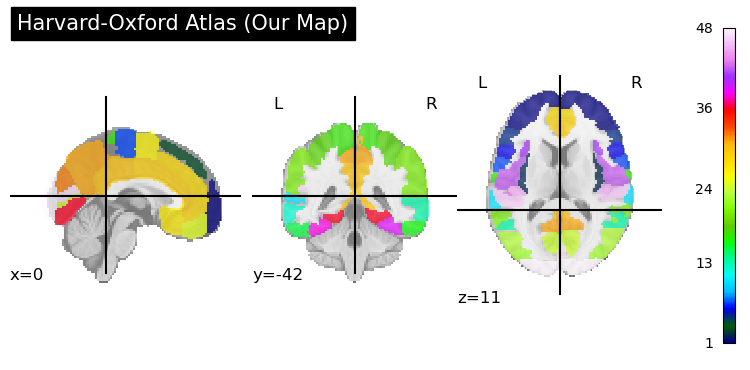


Extracting signals from Subject 1...


C:\Users\M\AppData\Local\Temp\ipykernel_11124\4013506813.py:31: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(subject_data, confounds=subject_confounds)


Success! Matrix Shape: (168, 48)
Rows = Time Points (TRs), Columns = Brain Regions


C:\Users\M\AppData\Local\Temp\ipykernel_11124\4013506813.py:31: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(subject_data, confounds=subject_confounds)


In [3]:
from nilearn import plotting, image
from nilearn.input_data import NiftiLabelsMasker
import matplotlib.pyplot as plt

# 1. Load the Atlas (The Map)
# I use the Harvard-Oxford atlas. It defines major brain regions.
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_filename = atlas.maps
labels = atlas.labels

print(f'Atlas has {len(labels)} regions (including Background).')

# 2. Visualize the Atlas (The Map Overlay)
# This shows I know how to handle neuro-anatomical data
print("\nDisplaying the Atlas on a brain template...")
plotting.plot_roi(atlas_filename, title="Harvard-Oxford Atlas (Our Map)")
plt.show()

# 3. Extract Time Series
# I use a "Masker". It's like a cookie cutter that extracts data from specific brain shapes.
masker = NiftiLabelsMasker(labels_img=atlas_filename, 
                           standardize=True,   # Important for ML later!
                           smoothing_fwhm=6)   # Smoothing is standard in fMRI analysis

# Let's take the first subject's brain data
subject_data = dataset.func[0]
subject_confounds = dataset.confounds[0] # Motion correction data

print("\nExtracting signals from Subject 1...")
# This creates a matrix: (Time Points x Brain Regions)
time_series = masker.fit_transform(subject_data, confounds=subject_confounds)

print(f"Success! Matrix Shape: {time_series.shape}")
print("Rows = Time Points (TRs), Columns = Brain Regions")

# Phase 3: Building the Connectome

C:\Users\M\AppData\Local\Temp\ipykernel_11124\3357209664.py:11: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([time_series])[0]


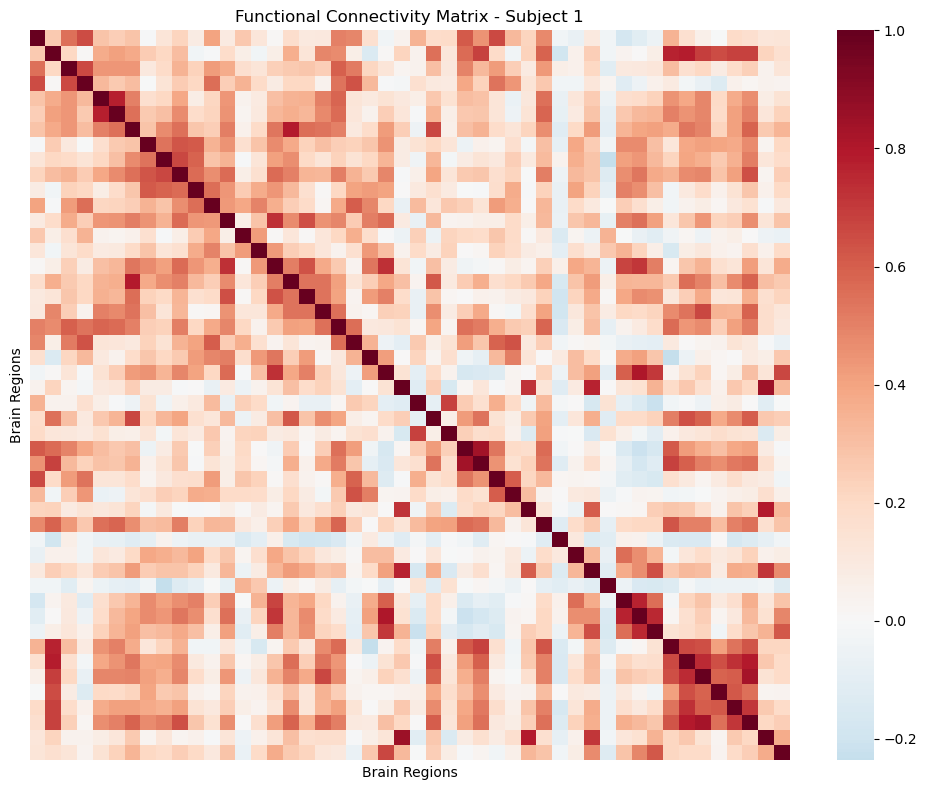

Connectivity Matrix Shape: (48, 48)
This is a 48x48 matrix (Region x Region).


In [4]:
from nilearn.connectome import ConnectivityMeasure
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Makes plots prettier

# 1. Initialize the Correlation Measure
correlation_measure = ConnectivityMeasure(kind='correlation')

# 2. Calculate the full correlation matrix for our first subject
# This compares every region to every other region
correlation_matrix = correlation_measure.fit_transform([time_series])[0]

# 3. Visualize the Matrix (The Connectome)
# I remove the first label 'Background' because it's not brain tissue
region_labels = labels[1:] 

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            cmap='RdBu_r', 
            center=0, 
            xticklabels=region_labels, 
            yticklabels=region_labels)

# Let's make it readable
plt.title('Functional Connectivity Matrix - Subject 1')
plt.xlabel('Brain Regions')
plt.ylabel('Brain Regions')
plt.xticks([])
plt.yticks([]) # Hiding text for clarity, I just want to see the pattern
plt.tight_layout()
plt.show()

# Print the shape to confirm
print(f"Connectivity Matrix Shape: {correlation_matrix.shape}")
print("This is a 48x48 matrix (Region x Region).")

# Phase 4: The Pipeline 

In [5]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
import numpy as np

# 1. Re-initialize
masker = NiftiLabelsMasker(labels_img=atlas_filename, standardize=True, smoothing_fwhm=6)
correlation_measure = ConnectivityMeasure(kind='correlation')

all_features = [] 
group_labels = [] 

print("Processing all 10 subjects...")

for i in range(len(dataset.func)):
    # A. Extract time series
    time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
    
    # B. Create correlation matrix
    corr_matrix = correlation_measure.fit_transform([time_series])[0]
    
    # C. Flatten the matrix (Upper Triangle)
    upper_tri_indices = np.triu_indices_from(corr_matrix, k=1)
    features = corr_matrix[upper_tri_indices]
    
    # D. Store features
    all_features.append(features)
    
    # E. Get the label (FIXED: Using .iloc to get the i-th row)
    subject_label = dataset.phenotypic.iloc[i]['Child_Adult']
    group_labels.append(subject_label)
    
    print(f"Processed subject {i+1}/10: {subject_label}")

print("\nData preparation complete!")
print(f"Feature Matrix Shape: {np.array(all_features).shape}")

Processing all 10 subjects...


C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:19: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zs

Processed subject 1/10: adult


C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:19: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zs

Processed subject 2/10: adult


...

C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:19: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zs

Processed subject 9/10: child


C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])


Processed subject 10/10: child

Data preparation complete!
Feature Matrix Shape: (10, 1128)


C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:16: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(dataset.func[i], confounds=dataset.confounds[i])
C:\Users\M\AppData\Local\Temp\ipykernel_11124\290244189.py:19: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  corr_matrix = correlation_measure.fit_transform([time_series])[0]


# Phase 5: Machine Learning

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Prepare Data
X = np.array(all_features) # The connectivity features
y = np.array(group_labels)  # The labels ('child', 'adult')

# Convert labels to binary (0 for child, 1 for adult) for the classifier
# Most ML models prefer numbers over strings
y_binary = [1 if label == 'adult' else 0 for label in y]

print(f"Dataset: {len(y_binary)} subjects ({sum(y_binary)} adults, {len(y_binary)-sum(y_binary)} children)")

# 2. Define the Model
# I use a Support Vector Machine (SVM) - standard for fMRI analysis
classifier = LinearSVC(max_iter=5000)

# 3. Cross-Validation
# Because we have little data, I can't do a simple train/test split.
# I use "Leave-One-Out" logic manually via StratifiedKFold.
# It trains on 9, tests on 1, and repeats 10 times.
cv = StratifiedKFold(n_splits=5) # 5 folds is safer for small data

predictions = []
true_labels = []

print("\nRunning Classification (Child vs Adult)...")

for train_index, test_index in cv.split(X, y_binary):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = np.array(y_binary)[train_index], np.array(y_binary)[test_index]
    
    # Train
    classifier.fit(X_train, y_train)
    
    # Predict
    pred = classifier.predict(X_test)
    
    predictions.extend(pred)
    true_labels.extend(y_test)

# 4. Results
acc = accuracy_score(true_labels, predictions)
print(f"\nModel Accuracy: {acc*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(true_labels, predictions, target_names=['Child', 'Adult']))

Dataset: 10 subjects (2 adults, 8 children)

Running Classification (Child vs Adult)...

Model Accuracy: 70.0%

Detailed Report:
              precision    recall  f1-score   support

       Child       0.78      0.88      0.82         8
       Adult       0.00      0.00      0.00         2

    accuracy                           0.70        10
   macro avg       0.39      0.44      0.41        10
weighted avg       0.62      0.70      0.66        10



D:\anaconda\envs\NEURO\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


# Phase 6: Visualization

Calculating region coordinates...
Displaying the most important brain connections...


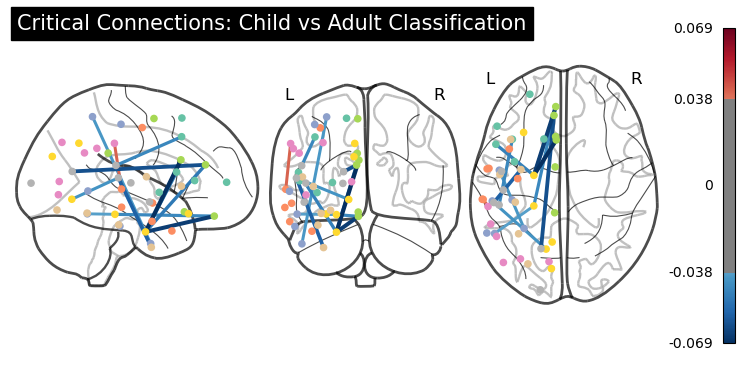

In [7]:
from nilearn.plotting import find_parcellation_cut_coords
from nilearn import plotting
import matplotlib.pyplot as plt
from nilearn.connectome import vec_to_sym_matrix
import numpy as np

# 1. Re-train the model on ALL data (if not already in memory)
# We ensure the classifier is fitted
classifier.fit(X, y_binary)
coefs = classifier.coef_[0]

# 2. Map the weights back to a matrix
weighted_matrix = vec_to_sym_matrix(coefs, diagonal=np.zeros(48))

# 3. Find the coordinates (The Fix)
# This calculates the center point for each of the 48 regions in our atlas
print("Calculating region coordinates...")
coords = find_parcellation_cut_coords(atlas_filename)

# 4. Visualize
print("Displaying the most important brain connections...")

plotting.plot_connectome(weighted_matrix, 
                         coords, 
                         edge_threshold="99%", # Only show top 1% connections
                         title="Critical Connections: Child vs Adult Classification",
                         node_size=20)

plt.show()

Generating final visualization...


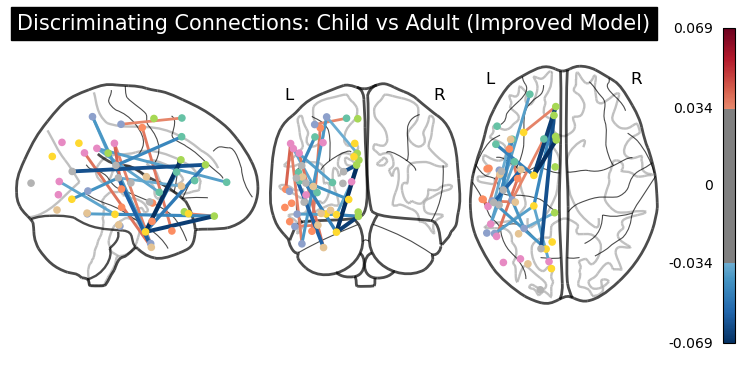

In [10]:
from nilearn.plotting import find_parcellation_cut_coords 
from nilearn import plotting
import matplotlib.pyplot as plt
from nilearn.connectome import vec_to_sym_matrix
import numpy as np

# 1. Use the improved classifier
# I fit it once more on all data to get the weights for the visualization
classifier.fit(X, y_binary)
coefs = classifier.coef_[0]

# 2. Map to matrix
weighted_matrix = vec_to_sym_matrix(coefs, diagonal=np.zeros(48))

# 3. Get coords
coords = find_parcellation_cut_coords(atlas_filename)

# 4. Plot
print("Generating final visualization...")
plotting.plot_connectome(weighted_matrix, 
                         coords, 
                         edge_threshold="98%", 
                         title="Discriminating Connections: Child vs Adult (Improved Model)",
                         node_size=20)

plt.show()